# Visualisation

In [8]:
from tslearn.datasets import UCR_UEA_datasets
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

Shape of the dataset:
X_train : (2459, 36, 6) (samples, time steps, channels)
X_test  : (2466, 36, 6)
Number of classes : 14
Channels per series : 6 (Bands u, g, r, i, z, y)
Time steps : 36
Class 15 : 123 samples (5.0%)
Class 16 : 270 samples (11.0%)
Class 42 : 381 samples (15.5%)
Class 52 : 62 samples (2.5%)
Class 53 : 7 samples (0.3%)
Class 6 : 34 samples (1.4%)
Class 62 : 153 samples (6.2%)
Class 64 : 23 samples (0.9%)
Class 65 : 313 samples (12.7%)
Class 67 : 68 samples (2.8%)
Class 88 : 120 samples (4.9%)
Class 90 : 777 samples (31.6%)
Class 92 : 77 samples (3.1%)
Class 95 : 51 samples (2.1%)


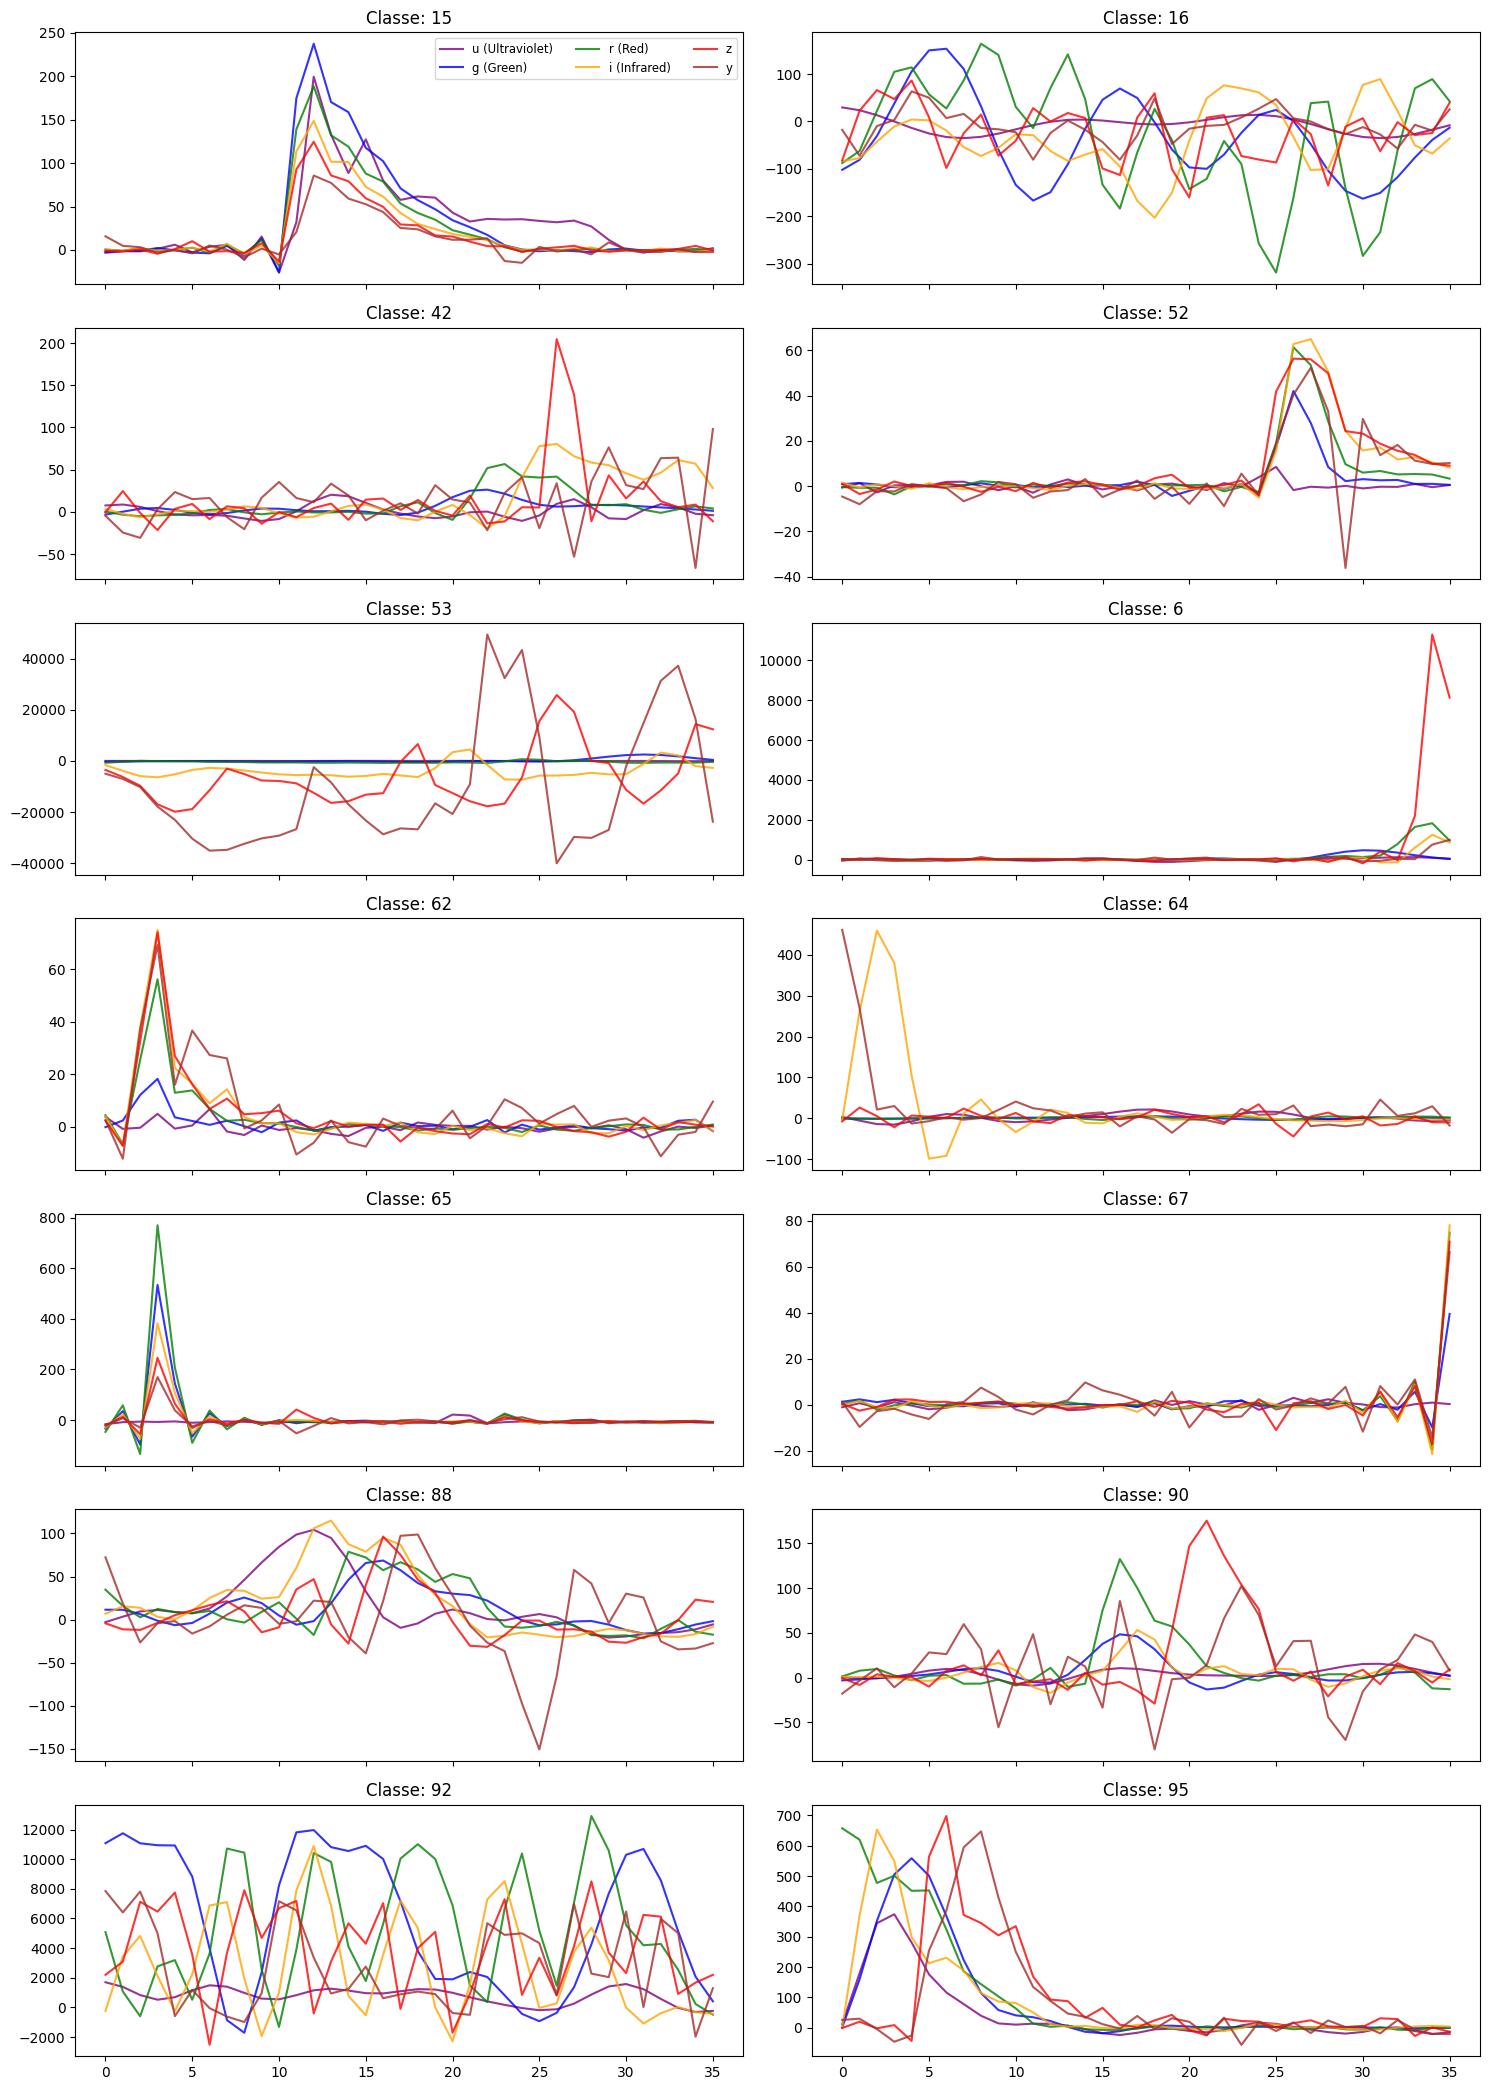

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Simple statistics
classes, counts = np.unique(y_train, return_counts=True)
n_classes = len(classes)
n_timestamps = X_train.shape[1]
n_channels = X_train.shape[2]

print("Shape of the dataset:")
print(f"X_train : {X_train.shape} (samples, time steps, channels)")
print(f"X_test  : {X_test.shape}")
print(f"Number of classes : {n_classes}")
print(f"Channels per series : {n_channels} (Bands u, g, r, i, z, y)")
print(f"Time steps : {n_timestamps}")


for c, count in zip(classes, counts):
    print(f"Class {c} : {count} samples ({count/len(y_train)*100:.1f}%)")

# Visualisation for the first sample of each class
channel_names = ['u (Ultraviolet)', 'g (Green)', 'r (Red)', 'i (Infrared)', 'z', 'y']
colors = ['purple', 'blue', 'green', 'orange', 'red', 'brown']

cols = 2
rows = math.ceil(n_classes / cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows), sharex=True)
axes = axes.flatten()

for i, c in enumerate(classes):
    # Find the first sample of class c
    idx = np.where(y_train == c)[0][0]
    sample = X_train[idx]
    
    # Draw the 6 channels for this sample
    for ch in range(n_channels):
        axes[i].plot(sample[:, ch], label=f'{channel_names[ch]}', color=colors[ch], alpha=0.8)
        
    axes[i].set_title(f'Classe: {c}')
    if i == 0:
        axes[i].legend(loc='upper right', fontsize='small', ncol=3)

# Cleaning
for j in range(len(classes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

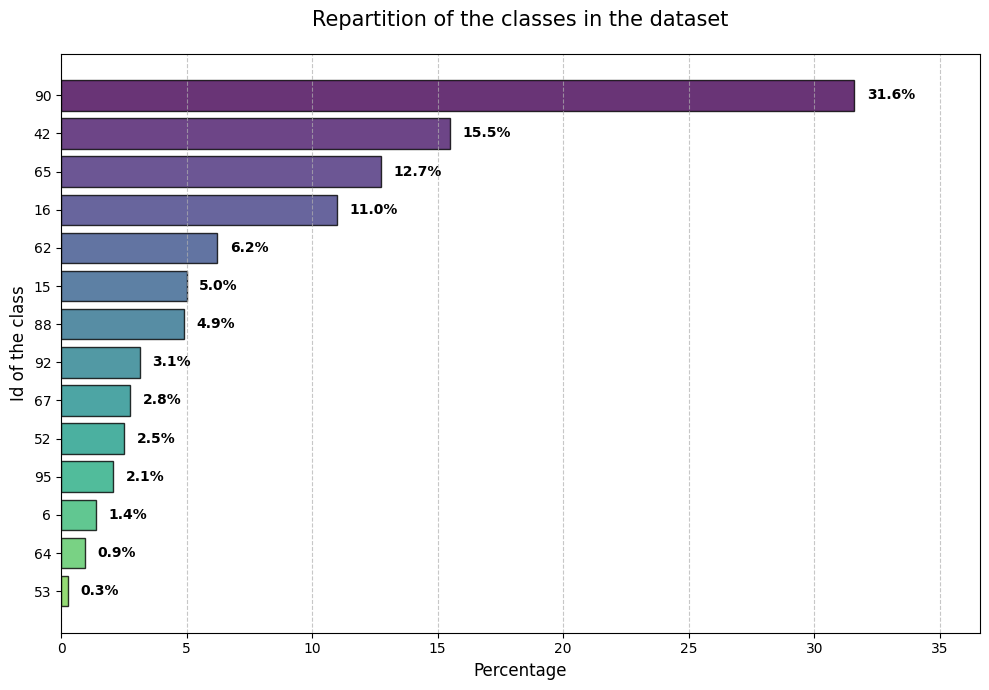

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcul des statistiques
classes, counts = np.unique(y_train, return_counts=True)
percentages = (counts / len(y_train)) * 100

# 2. Tri des données (du plus fréquent au moins fréquent) pour un look "propre"
sorted_indices = np.argsort(percentages)[::-1]
sorted_classes = classes[sorted_indices].astype(str)
sorted_percentages = percentages[sorted_indices]

# 3. Création du graphique
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0, 0.8, n_classes)) # Dégradé de couleurs

bars = plt.barh(sorted_classes, sorted_percentages, color=colors, edgecolor='black', alpha=0.8)

# 4. Ajout des étiquettes de pourcentage au bout de chaque barre
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=10, fontweight='bold')

# 5. Cosmétique et labels
plt.title('Repartition of the classes in the dataset', fontsize=15, pad=20)
plt.xlabel('Percentage', fontsize=12)
plt.ylabel('Id of the class', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(percentages) + 5) # Laisser de la place pour le texte
plt.gca().invert_yaxis() # Inverser pour avoir la classe la plus fréquente en haut

plt.tight_layout()
plt.show()

# Baseline

In [11]:
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from aeon.transformations.collection.convolution_based import Rocket

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Conversion 
# tslearn = (n_samples, n_timestamps, n_channels)
# aeon = (n_samples, n_channels, n_timestamps)
X_train_aeon = np.transpose(X_train, (0, 2, 1))
X_test_aeon = np.transpose(X_test, (0, 2, 1))

print(f"Corrected data format : {X_train_aeon.shape}")

# Feature extraction with ROCKET
print("Extracting features with ROCKET")
# By default, ROCKET uses 10,000 random kernels
rocket = Rocket()
X_train_features = rocket.fit_transform(X_train_aeon)
X_test_features = rocket.transform(X_test_aeon)

print(f"Shape of the extracted features : {X_train_features.shape}")

# Training the Ridge classifier
classifier = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
classifier.fit(X_train_features, y_train_encoded)

# 5. Evaluation
y_pred = classifier.predict(X_test_features)

accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\n---> Accuracy of the ROCKET Baseline : {accuracy:.4f} <---")

print("\nDetailed classification report :")
print(classification_report(y_test_encoded, y_pred, target_names=[str(c) for c in label_encoder.classes_]))

Corrected data format : (2459, 6, 36)
Extracting features with ROCKET
Shape of the extracted features : (2459, 20000)

---> Accuracy of the ROCKET Baseline : 0.5454 <---

Detailed classification report :
              precision    recall  f1-score   support

          15       0.40      0.29      0.34       124
          16       0.78      0.80      0.79       270
          42       0.37      0.45      0.40       382
          52       0.07      0.03      0.04        63
          53       0.00      0.00      0.00         7
           6       0.38      0.09      0.14        35
          62       0.22      0.19      0.20       153
          64       0.00      0.00      0.00        24
          65       0.73      0.73      0.73       313
          67       0.29      0.10      0.15        68
          88       0.87      0.79      0.83       121
          90       0.55      0.68      0.61       777
          92       0.69      0.32      0.44        77
          95       0.28      0.13      

c:\Users\bapti\miniconda3\envs\advanced_ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bapti\miniconda3\envs\advanced_ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bapti\miniconda3\envs\advanced_ml\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

## Setting 2: Pre-train on forecasting (Informer datasets only), adapt on classification

In [12]:
import torch
import torch.nn as nn

class TimeSeriesEncoderCI(nn.Module):
    """Encodeur Channel-Independent"""
    def __init__(self, hidden_dim): 
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim * 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Pooling global sur l'axe du temps
        )

        self.output_dim_per_channel = hidden_dim * 2

    def forward(self, x):
        # x shape initiale : (batch_size, num_channels, seq_len)
        batch_size, num_channels, seq_len = x.shape
        
        # x_ci shape : (batch_size * num_channels, 1, seq_len)
        x_ci = x.reshape(batch_size * num_channels, 1, seq_len)

        features = self.conv_block(x_ci) # Sortie : (batch_size * num_channels, output_dim_per_channel, 1)
        features = features.squeeze(-1)  # Sortie : (batch_size * num_channels, output_dim_per_channel)
        
        features = features.reshape(batch_size, num_channels, self.output_dim_per_channel)
        
        # Sortie finale : (batch_size, num_channels * output_dim_per_channel)
        return features.flatten(start_dim=1)


class ForecastingModel(nn.Module):
    """Tête de Prévision (pour Informer)"""
    def __init__(self, encoder, num_channels, horizon):
        super().__init__()
        self.encoder = encoder
        in_features = num_channels * encoder.output_dim_per_channel
        self.head = nn.Linear(in_features, horizon)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)


class ClassificationModel(nn.Module):
    """Tête de Classification (pour LSST)"""
    def __init__(self, encoder, num_channels, num_classes):
        super().__init__()
        self.encoder = encoder
        in_features = num_channels * encoder.output_dim_per_channel
        self.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

#  Hyperparamètres (simulés pour un dataset Informer)
in_channels = 7      # Ex: Le dataset ETTh1 a 7 variables (canaux)
seq_len_past = 96    # On regarde 96 pas de temps dans le passé
horizon = 24         # On veut prédire les 24 pas de temps futurs
hidden_dim = 64

# 2. Initialisation du modèle
encoder = TimeSeriesEncoderCI(hidden_dim=64) 
forecasting_model = ForecastingModel(encoder, num_channels=7, horizon=24)


criterion = nn.MSELoss() # MSE
optimizer = optim.Adam(forecasting_model.parameters(), lr=1e-3)

# 3. Boucle d'entraînement (Simulation)
print("Début du pré-entraînement sur Informer Datasets...")
forecasting_model.train()

# Simule un DataLoader avec des données Informer
for epoch in range(100): 
    # A remplacer par les données Informer réelles
    X_past = torch.randn(32, in_channels, seq_len_past) # (Batch, Canaux, Temps)
    Y_future = torch.randn(32, horizon) # La cible : horizon futur
    optimizer.zero_grad()
    predictions = forecasting_model(X_past)
    loss = criterion(predictions, Y_future)
    loss.backward()
    optimizer.step()
    
    print(f"Epoch {epoch+1} | MSE Loss: {loss.item():.4f}")

torch.save(encoder.state_dict(), "pretrained_encoder.pth")

Début du pré-entraînement sur Informer Datasets...
Epoch 1 | MSE Loss: 1.0708
Epoch 2 | MSE Loss: 0.9659
Epoch 3 | MSE Loss: 1.0870
Epoch 4 | MSE Loss: 1.0152
Epoch 5 | MSE Loss: 0.9892
Epoch 6 | MSE Loss: 1.0306
Epoch 7 | MSE Loss: 0.9802
Epoch 8 | MSE Loss: 1.0230
Epoch 9 | MSE Loss: 1.1068
Epoch 10 | MSE Loss: 1.0752
Epoch 11 | MSE Loss: 1.0550
Epoch 12 | MSE Loss: 1.0965
Epoch 13 | MSE Loss: 1.0130
Epoch 14 | MSE Loss: 0.9945
Epoch 15 | MSE Loss: 1.0578
Epoch 16 | MSE Loss: 1.0139
Epoch 17 | MSE Loss: 1.1806
Epoch 18 | MSE Loss: 1.0733
Epoch 19 | MSE Loss: 1.0782
Epoch 20 | MSE Loss: 0.9855
Epoch 21 | MSE Loss: 1.0742
Epoch 22 | MSE Loss: 1.0059
Epoch 23 | MSE Loss: 1.0414
Epoch 24 | MSE Loss: 1.0260
Epoch 25 | MSE Loss: 1.0821
Epoch 26 | MSE Loss: 1.0150
Epoch 27 | MSE Loss: 1.0975
Epoch 28 | MSE Loss: 0.9896
Epoch 29 | MSE Loss: 1.0680
Epoch 30 | MSE Loss: 1.0403
Epoch 31 | MSE Loss: 1.0210
Epoch 32 | MSE Loss: 1.1224
Epoch 33 | MSE Loss: 1.0484
Epoch 34 | MSE Loss: 1.0248
Epoch 

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tslearn.datasets import UCR_UEA_datasets
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)

# Format PyTorch : (Batch, Canaux, Temps)
X_train_pt = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)
y_train_pt = torch.tensor(y_train_encoded, dtype=torch.long)

in_channels_lsst = X_train_pt.shape[1] # LSST a 6 canaux
n_classes = len(np.unique(y_train_encoded)) # 14 classes

encoder = TimeSeriesEncoderCI(hidden_dim=64) 

# CHARGEMENT DES POIDS PRÉ-ENTRAÎNÉS
try:
    # strict=False permet d'ignorer la première couche si le nombre de canaux diffère
    encoder.load_state_dict(torch.load("pretrained_encoder.pth"), strict=False)
except FileNotFoundError:
    print("Fichier pretrained_encoder.pth non trouvé. Entraînement from scratch.")

classification_model = ClassificationModel(encoder, num_channels=6, num_classes=14)

# OPTIONNEL : Linear Probing (Geler l'encodeur)
# for param in classification_model.encoder.parameters():
#     param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classification_model.parameters(), lr=1e-4) # Learning rate plus petit pour le fine-tuning

# 3. Entraînement (Fine-tuning)
classification_model.train()

for epoch in range(100):
    optimizer.zero_grad()
    predictions = classification_model(X_train_pt)
    loss = criterion(predictions, y_train_pt)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1} | Classification Loss: {loss.item():.4f}")

C:\Users\bapti\AppData\Local\Temp\ipykernel_34640\1255845958.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load("pretrained_encoder.pth"

Epoch 1 | Classification Loss: 2.6293
Epoch 2 | Classification Loss: 2.6205
Epoch 3 | Classification Loss: 2.6123
Epoch 4 | Classification Loss: 2.6049
Epoch 5 | Classification Loss: 2.5982
Epoch 6 | Classification Loss: 2.5920
Epoch 7 | Classification Loss: 2.5864
Epoch 8 | Classification Loss: 2.5812
Epoch 9 | Classification Loss: 2.5764
Epoch 10 | Classification Loss: 2.5719
Epoch 11 | Classification Loss: 2.5676
Epoch 12 | Classification Loss: 2.5636
Epoch 13 | Classification Loss: 2.5596
Epoch 14 | Classification Loss: 2.5558
Epoch 15 | Classification Loss: 2.5521
Epoch 16 | Classification Loss: 2.5485
Epoch 17 | Classification Loss: 2.5450
Epoch 18 | Classification Loss: 2.5416
Epoch 19 | Classification Loss: 2.5382
Epoch 20 | Classification Loss: 2.5348
Epoch 21 | Classification Loss: 2.5315
Epoch 22 | Classification Loss: 2.5283
Epoch 23 | Classification Loss: 2.5251
Epoch 24 | Classification Loss: 2.5219
Epoch 25 | Classification Loss: 2.5187
Epoch 26 | Classification Loss: 2.

In [15]:
import torch
from torch.utils.data import Dataset
import numpy as np

class InformerForecastingDataset(Dataset):
    """
    Dataset pour la phase 1 : Pré-entraînement (Forecasting).
    Prend une longue série temporelle multivariée et crée des fenêtres glissantes.
    """
    def __init__(self, data, seq_len_past, horizon):
        # data attendu : numpy array de forme (Total_Timestamps, Canaux)
        # Ex: (10000 heures, 7 variables météo)
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len_past = seq_len_past
        self.horizon = horizon

    def __len__(self):
        # Le nombre de fenêtres qu'on peut extraire
        return len(self.data) - self.seq_len_past - self.horizon + 1

    def __getitem__(self, idx):
        # On extrait le passé (X)
        x_past = self.data[idx : idx + self.seq_len_past]
        
        # On extrait le futur à prédire (Y)
        y_future = self.data[idx + self.seq_len_past : idx + self.seq_len_past + self.horizon]
        
        # PyTorch Conv1d attend le format (Canaux, Temps), on transpose donc avec permute
        x_past = x_past.permute(1, 0)
        y_future = y_future.permute(1, 0)
        
        return x_past, y_future


class LSSTClassificationDataset(Dataset):
    """
    Dataset pour la phase 2 : Adaptation (Fine-tuning sur LSST).
    """
    def __init__(self, X, y):
        # X attendu depuis tslearn : (Samples, Temps, Canaux)
        # y attendu : (Samples,) encodés de 0 à 13
        
        # On convertit en tenseurs et on transpose pour avoir (Samples, Canaux, Temps)
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]